In [ ]:
# This is part of the manuscript titled "Feedback-mediated circulation and persistence of stochastic fluctuations in gene regulatory circuits"

# Correspondence with the paper

# Please note ;
# 1. The four TNF motifs : Double positive(++), Double negative(--), Negative positive(-+) and Positive negative(+-) motifs
# 2. alpha_x and alpha_y are production rates of X and Y
# 3. beta_x and beta_y are degradation rates of X and Y
# 4. Atau is the time-scale asymmetry given by beta_x/beta_y (here Atau is a list of time-scale asymmetry values)
# 5. Txy and Tyx are time averaging factors
# 6. xav = < x >, yav = < y > obtained from the stochastic simulation using Gillespie algorithm
# 7. stochastic simulation results averaged over n=100000 trajectories, tend is the end time of each simulated trajectory
# 8. G = H (feedback gain)
# 9. a1,a2,a3,a4 are the propensities and a0 is the total propensity
# 10. fxyp and fyxp are the derivatives of the production terms or the Hill functions 
# 11. The data is exported and plotted 

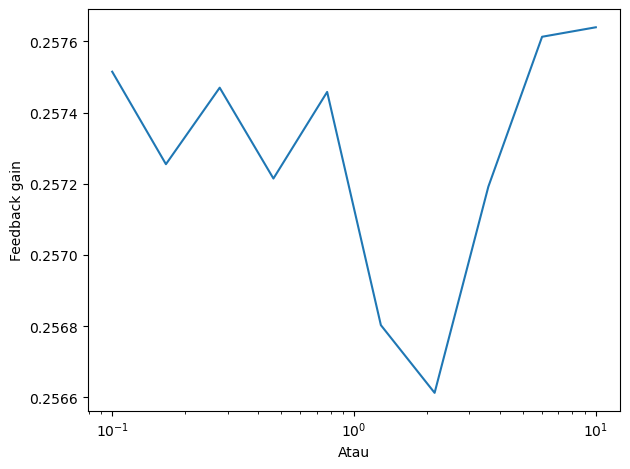

In [1]:
#double positive/ both activation

from numba import njit
import numpy as np
import matplotlib.pyplot as plt
import random

tend= 2000 #end time of the simulation
alpha_x=10
alpha_y=10
#beta_x=0.1
#beta_y=0.1
Atau=[0.1,0.1668,0.2783,0.4642,0.7743,1.2915,2.1544,3.5938,5.9948,10.0]
kxy=50
kyx=50
n=100000 #no.of realisations

@njit
def gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx):
    x, y, t = 50, 50, 0.0   #initial condition
    while t < tend:
        a1 = (alpha_x * y) / (kyx + y)
        a2 = beta_x * x
        a3 = (alpha_y * x) / (kxy + x)
        a4 = beta_y * y
        a0 = a1 + a2 + a3 + a4
        if a0 == 0:
            break
        r1 = np.random.random()
        r2 = np.random.random()
        t = t + (1/a0)*np.log(1/r1)  #update time
        
        #production of x
        if r2 * a0 < a1:
            x += 1  
        #decay of x
        elif r2 * a0 < (a1 + a2):
            x -= 1
        #production of y
        elif r2 * a0 < (a1 + a2 + a3):
            y += 1
        #decay of y 
        elif r2 * a0 < (a1 + a2 + a3 + a4):
            y -= 1
    return x, y

gain=[]

for at in Atau:
    beta_x=(0.1)*np.sqrt(at)
    beta_y=(0.1)/(np.sqrt(at))
    
    x_last=[]      #to append last value(steady state) of each realisation
    y_last=[]
    
    for i in range(n):
        x, y = gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx)
        x_last.append(x)
        y_last.append(y)
        
    xav = np.mean(x_last)
    yav = np.mean(y_last)
    
    #Derivatives
    fxyp= (alpha_x*kyx)/((yav+kyx)**2)
    fyxp= (alpha_y*kxy)/((xav+kxy)**2)
    
    #feedback gain
    G=(fxyp*fyxp)/(beta_x*beta_y)
    gain.append(G)
    
plt.xscale('log')
plt.plot(Atau,gain)


plt.ylabel("Feedback gain")
plt.xlabel("Atau")

np.savetxt('DPa_gain.dat',np.column_stack((Atau,gain)), comments='', fmt="%.6f", delimiter="\t")

plt.tight_layout()
plt.show()

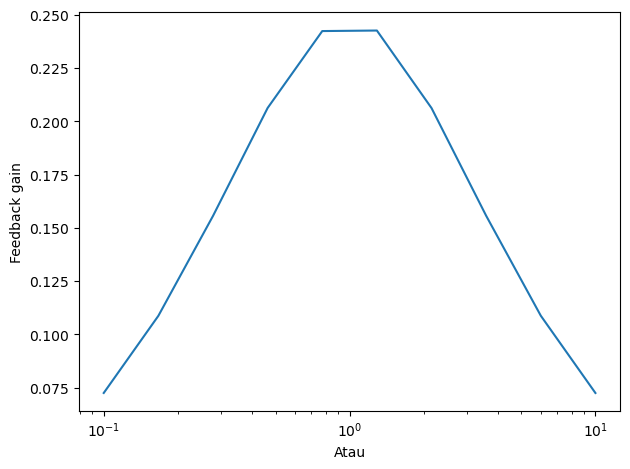

In [2]:
#double negative/ both repression

from numba import njit
import numpy as np
import matplotlib.pyplot as plt
import random

tend= 2000 #end time of the simulation
alpha_x=10
alpha_y=10
#beta_x=0.1
#beta_y=0.1
Atau=[0.1,0.1668,0.2783,0.4642,0.7743,1.2915,2.1544,3.5938,5.9948,10.0]
kxy=50
kyx=50
n=100000 #no.of realisations

@njit
def gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx):
    x, y, t = 50, 50, 0.0   #initial condition
    while t < tend:
        a1 = (alpha_x * kyx) / (kyx + y)
        a2 = beta_x * x
        a3 = (alpha_y * kxy) / (kxy + x)
        a4 = beta_y * y
        a0 = a1 + a2 + a3 + a4
        if a0 == 0:
            break
        r1 = np.random.random()
        r2 = np.random.random()
        t = t + (1/a0)*np.log(1/r1)  #update time
        
        #production of x
        if r2 * a0 < a1:
            x += 1  
        #decay of x
        elif r2 * a0 < (a1 + a2):
            x -= 1
        #production of y
        elif r2 * a0 < (a1 + a2 + a3):
            y += 1
        #decay of y 
        elif r2 * a0 < (a1 + a2 + a3 + a4):
            y -= 1
    return x, y

gain=[]

for at in Atau:
    beta_x=(0.1)*np.sqrt(at)
    beta_y=(0.1)/(np.sqrt(at))
    
    x_last=[]      #to append last value(steady state) of each realisation
    y_last=[]
    
    for i in range(n):
        x, y = gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx)
        x_last.append(x)
        y_last.append(y)
        
    xav = np.mean(x_last)
    yav = np.mean(y_last)
    
    #Derivatives
    fxyp= (-alpha_x*kyx)/((yav+kyx)**2)
    fyxp= (-alpha_y*kxy)/((xav+kxy)**2)
    
    #feedback gain
    G=(fxyp*fyxp)/(beta_x*beta_y)
    gain.append(G)
    
plt.xscale('log')
plt.plot(Atau,gain)


plt.ylabel("Feedback gain")
plt.xlabel("Atau")

np.savetxt('DNa_gain.dat',np.column_stack((Atau,gain)), comments='', fmt="%.6f", delimiter="\t")

plt.tight_layout()
plt.show()

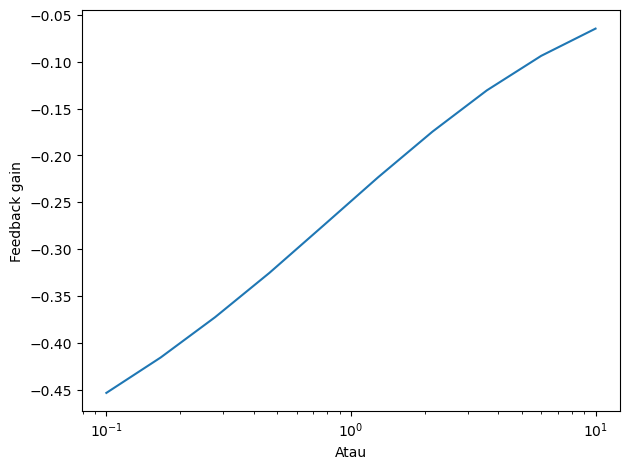

In [3]:
#negative positive/ x represses y, y activates x

from numba import njit
import numpy as np
import matplotlib.pyplot as plt
import random

tend= 2000 #end time of the simulation
alpha_x=10
alpha_y=10
#beta_x=0.1
#beta_y=0.1
Atau=[0.1,0.1668,0.2783,0.4642,0.7743,1.2915,2.1544,3.5938,5.9948,10.0]
kxy=50
kyx=50
n=100000 #no.of realisations

@njit
def gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx):
    x, y, t = 50, 50, 0.0   #initial condition
    while t < tend:
        a1 = (alpha_x * y) / (kyx + y)
        a2 = beta_x * x
        a3 = (alpha_y * kxy) / (kxy + x)
        a4 = beta_y * y
        a0 = a1 + a2 + a3 + a4
        if a0 == 0:
            break
        r1 = np.random.random()
        r2 = np.random.random()
        t = t + (1/a0)*np.log(1/r1)  #update time
        
        #production of x
        if r2 * a0 < a1:
            x += 1  
        #decay of x
        elif r2 * a0 < (a1 + a2):
            x -= 1
        #production of y
        elif r2 * a0 < (a1 + a2 + a3):
            y += 1
        #decay of y 
        elif r2 * a0 < (a1 + a2 + a3 + a4):
            y -= 1
    return x, y

gain=[]

for at in Atau:
    beta_x=(0.1)*np.sqrt(at)
    beta_y=(0.1)/(np.sqrt(at))
    
    x_last=[]      #to append last value(steady state) of each realisation
    y_last=[]
    
    for i in range(n):
        x, y = gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx)
        x_last.append(x)
        y_last.append(y)
        
    xav = np.mean(x_last)
    yav = np.mean(y_last)
    
    #Derivatives
    fxyp= (alpha_x*kyx)/((yav+kyx)**2)
    fyxp= (-alpha_y*kxy)/((xav+kxy)**2)
    
    #feedback gain
    G=(fxyp*fyxp)/(beta_x*beta_y)
    gain.append(G)
    
plt.xscale('log')
plt.plot(Atau,gain)

plt.ylabel("Feedback gain")
plt.xlabel("Atau")

np.savetxt('NPa_gain.dat',np.column_stack((Atau,gain)), comments='', fmt="%.6f", delimiter="\t")

plt.tight_layout()
plt.show()

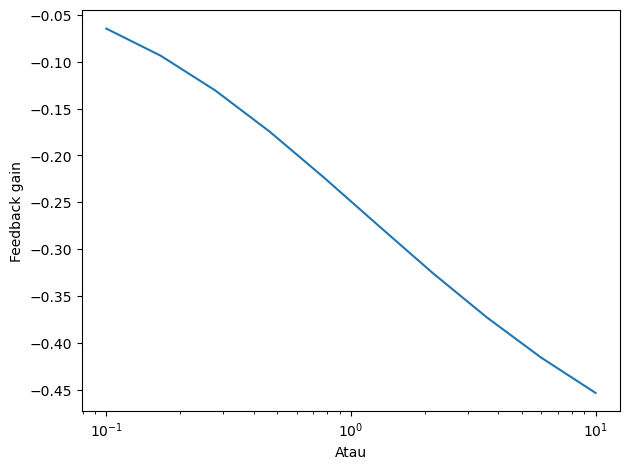

In [4]:
#positive negative/ x activates y, y represses x

from numba import njit
import numpy as np
import matplotlib.pyplot as plt
import random

tend= 2000 #end time of the simulation
alpha_x=10
alpha_y=10
#beta_x=0.1
#beta_y=0.1
Atau=[0.1,0.1668,0.2783,0.4642,0.7743,1.2915,2.1544,3.5938,5.9948,10.0]
kxy=50
kyx=50
n=100000 #no.of realisations

@njit
def gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx):
    x, y, t = 50, 50, 0.0   #initial condition
    while t < tend:
        a1 = (alpha_x * kyx) / (kyx + y)
        a2 = beta_x * x
        a3 = (alpha_y * x) / (kxy + x)
        a4 = beta_y * y
        a0 = a1 + a2 + a3 + a4
        if a0 == 0:
            break
        r1 = np.random.random()
        r2 = np.random.random()
        t = t + (1/a0)*np.log(1/r1)  #update time
        
        #production of x
        if r2 * a0 < a1:
            x += 1  
        #decay of x
        elif r2 * a0 < (a1 + a2):
            x -= 1
        #production of y
        elif r2 * a0 < (a1 + a2 + a3):
            y += 1
        #decay of y 
        elif r2 * a0 < (a1 + a2 + a3 + a4):
            y -= 1
    return x, y

gain=[]

for at in Atau:
    beta_x=(0.1)*np.sqrt(at)
    beta_y=(0.1)/(np.sqrt(at))
    
    x_last=[]      #to append last value(steady state) of each realisation
    y_last=[]
    
    for i in range(n):
        x, y = gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx)
        x_last.append(x)
        y_last.append(y)
        
    xav = np.mean(x_last)
    yav = np.mean(y_last)
    
    #Derivatives
    fxyp= (-alpha_x*kyx)/((yav+kyx)**2)
    fyxp= (alpha_y*kxy)/((xav+kxy)**2)
    
    #feedback gain
    G=(fxyp*fyxp)/(beta_x*beta_y)
    gain.append(G)
    
plt.xscale('log')
plt.plot(Atau,gain)

plt.ylabel("Feedback gain")
plt.xlabel("Atau")

np.savetxt('PNa_gain.dat',np.column_stack((Atau,gain)), comments='', fmt="%.6f", delimiter="\t")

plt.tight_layout()
plt.show()